In [247]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Part 1

In [248]:
df=pd.read_csv('covid_19_clean_complete.csv')

In [249]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [250]:
df.shape

(49068, 10)

In [251]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [252]:
df.describe()

,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


## Quetsions:
# Q1: What does each row represent?  
->Each row represents a daily snapshot of COVID-19 metrics (Confirmed, Deaths, Recovered, and Active cases) for a specific country or geographical regoin on a specific date
# Q2: What are the main features available in the dataset?
->Geographical Features: Province/State, Country/Region, Lat, Long, and WHO Region.

->Temporal Features: Date. 

->Clinical features: Confirmed, Deaths, Recovered, and Active. 
# Q3: Which columns are numerical and which are categorical?
-> Numerical: Lat,Long,Confirmed,Deaths,Recovered,Active

-> Categorical: Province/State, Country/Region, Date, WHO Region

In [253]:
df.isna().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

In [254]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [255]:
missing_data=pd.DataFrame({
    "data type":df.dtypes.astype(str)
    ,'percnt':(df.isna().sum())/(len(df))
})
missing_data

,data type,percnt
Province/State,object,0.701149
Country/Region,object,0.000000
Lat,float64,0.000000
Long,float64,0.000000
Date,object,0.000000
Confirmed,int64,0.000000
Deaths,int64,0.000000
Recovered,int64,0.000000
Active,int64,0.000000
WHO Region,object,0.000000


In [256]:
df[df.duplicated()]
# NO duplicated recordes 

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region


In [257]:
df['Date']           # Date is stored appropretley

0        2020-01-22
1        2020-01-22
2        2020-01-22
3        2020-01-22
4        2020-01-22
            ...    
49063    2020-07-27
49064    2020-07-27
49065    2020-07-27
49066    2020-07-27
49067    2020-07-27
Name: Date, Length: 49068, dtype: object

In [258]:
df['Date']=pd.to_datetime(df['Date'])
df['Date']

0       2020-01-22
1       2020-01-22
2       2020-01-22
3       2020-01-22
4       2020-01-22
           ...    
49063   2020-07-27
49064   2020-07-27
49065   2020-07-27
49066   2020-07-27
49067   2020-07-27
Name: Date, Length: 49068, dtype: datetime64[ns]

In [259]:
df['Province/State']=df['Province/State'].fillna(df['Province/State'].mode()[0])

In [260]:
df['Province/State'].isna().sum()

np.int64(0)

## Part2:
# Q1: Which columns require cleaning?
-> 1- Province/State: because more than 70% represent missing values

-> 2- Date: because it is stored as an object not as a datetime64
# Q2: Which cleaning approach did you choose and why?
-> Date Conversion: using pd.to_datetime()

-> missing values by imputing it by mode

In [261]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

##  Q1:

In [262]:
t=df['Date'].max()
data=df[df['Date']==t]


In [263]:
print("The total number of Confirmed cases is",data['Confirmed'].sum())

The total number of Confirmed cases is 16480485


In [264]:
print("The total number of deaths is",data['Deaths'].sum())

The total number of deaths is 654036


In [265]:
print("The total number of recovery cases is",data['Recovered'].sum())

The total number of recovery cases is 9468087


In [266]:
print("The death rate",(data['Deaths'].sum()/data['Confirmed'].sum())*100)
print("The recovery rate",(data['Recovered'].sum()/data['Confirmed'].sum())*100)

The death rate 3.968548255709708
The recovery rate 57.450293483474546


## Q2:

In [267]:
data=df.groupby('Country/Region')[['Confirmed','Deaths','Recovered']].sum().reset_index()
data

,Country/Region,Confirmed,Deaths,Recovered
0,Afghanistan,1936390,49098,798240
1,Albania,196702,5708,118877
2,Algeria,1179755,77972,755897
3,Andorra,94404,5423,69074
4,Angola,22662,1078,6573
...,...,...,...,...
182,West Bank and Gaza,233461,1370,61124
183,Western Sahara,901,63,648
184,Yemen,67180,17707,23779
185,Zambia,129421,2643,83611


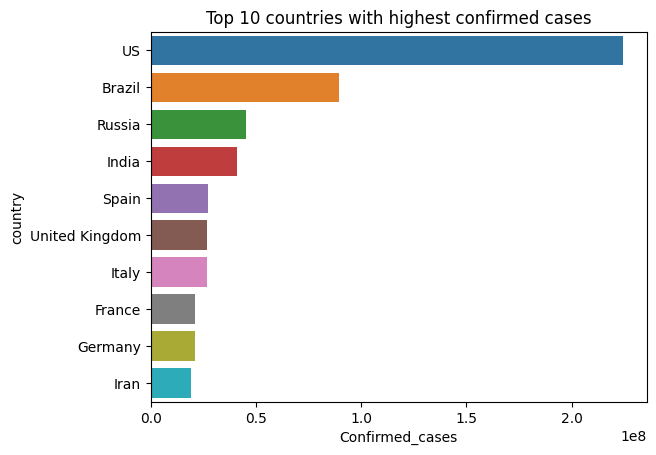

In [268]:
top_confirm=data.sort_values(by='Confirmed',ascending=False).head(10)
top_confirm[['Country/Region','Confirmed']]
sns.barplot(data=top_confirm,y='Country/Region',x='Confirmed',hue='Country/Region')
plt.title("Top 10 countries with highest confirmed cases")
plt.ylabel('country')
plt.xlabel('Confirmed_cases')
plt.show()

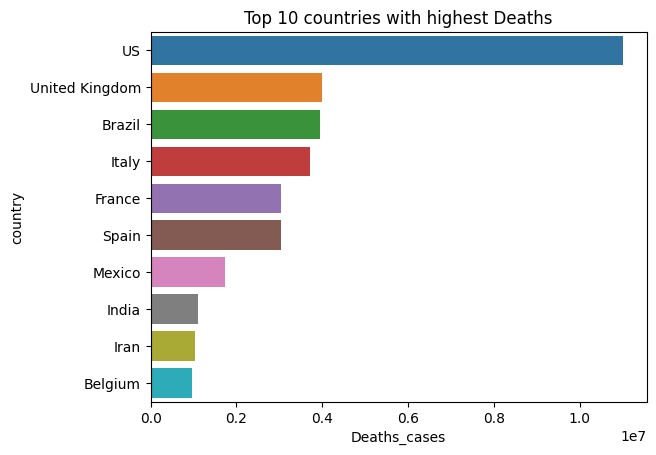

In [269]:
top_deaths=data.sort_values(by='Deaths',ascending=False).head(10)
top_deaths[['Country/Region','Deaths']]
sns.barplot(data=top_deaths,y='Country/Region',x='Deaths',hue='Country/Region')
plt.title("Top 10 countries with highest Deaths")
plt.ylabel('country')
plt.xlabel('Deaths_cases')
plt.show()

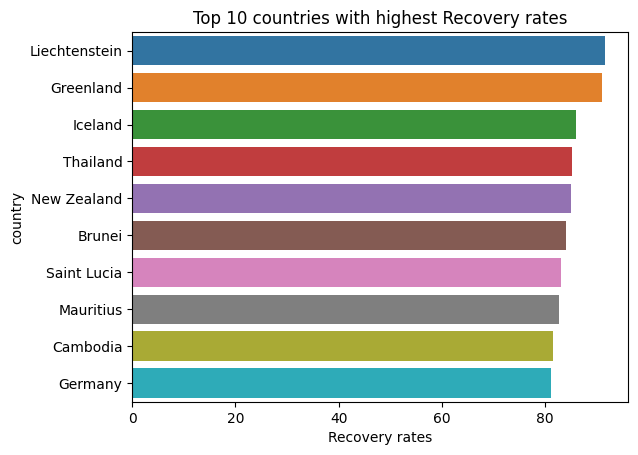

In [270]:
data["Recovery_Rate"] = (data["Recovered"] / data["Confirmed"]) * 100
top_recovery = data.sort_values(
    by="Recovery_Rate", ascending=False
).head(10)
top_recovery[["Country/Region", "Confirmed", "Recovery_Rate"]]
sns.barplot(data=top_recovery,y='Country/Region',x='Recovery_Rate',hue='Country/Region')
plt.title("Top 10 countries with highest Recovery rates")
plt.ylabel('country')
plt.xlabel('Recovery rates')
plt.show()

## Q2: 

In [271]:
daily_data = df.groupby("Date")[["Confirmed", "Deaths", "Recovered"]].sum().reset_index()
daily_data

,Date,Confirmed,Deaths,Recovered
0,2020-01-22,555,17,28
1,2020-01-23,654,18,30
2,2020-01-24,941,26,36
3,2020-01-25,1434,42,39
4,2020-01-26,2118,56,52
...,...,...,...,...
183,2020-07-23,15510481,633506,8710969
184,2020-07-24,15791645,639650,8939705
185,2020-07-25,16047190,644517,9158743
186,2020-07-26,16251796,648621,9293464


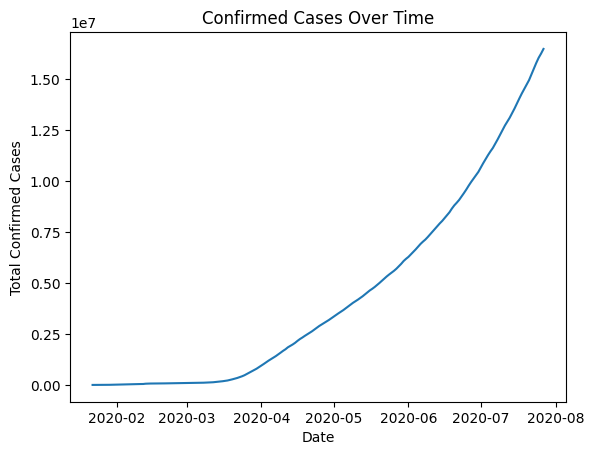

In [272]:
sns.lineplot(data=daily_data, x="Date", y="Confirmed")
plt.title("Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Total Confirmed Cases")
plt.show()

# Confirmed cases: Maintained a slow  progress between January and March 2020, followed by big growth beginning in April 2020

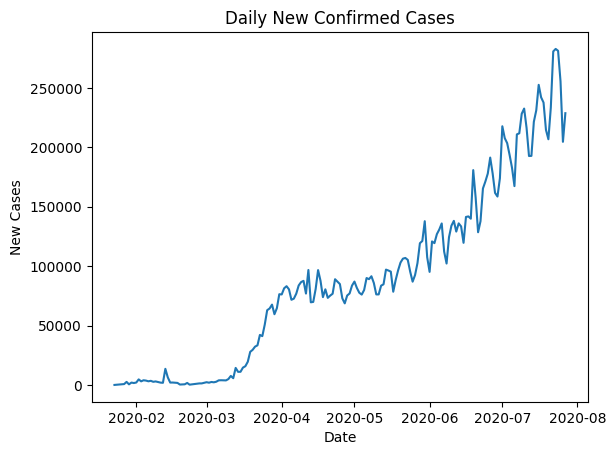

In [273]:
daily_data["New_Cases"] = daily_data["Confirmed"].diff()
max_increase = daily_data.sort_values(by="New_Cases", ascending=False).iloc[0]
sns.lineplot(data=daily_data, x="Date", y="New_Cases")
plt.title("Daily New Confirmed Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.show()

# The largest increase observed between june and july

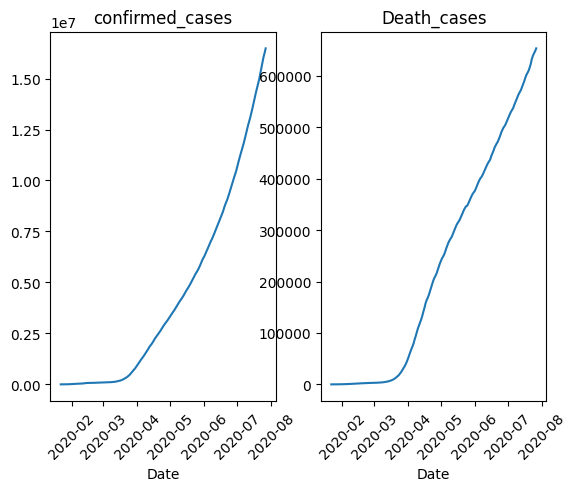

In [274]:
plt.subplot(1,2,1)
plt.plot(daily_data['Date'],daily_data['Confirmed'])
plt.title('confirmed_cases')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.subplot(1,2,2)
plt.plot(daily_data['Date'],daily_data['Deaths'])
plt.title('Death_cases')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.show()

# 

In [275]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  49068 non-null  object        
 1   Country/Region  49068 non-null  object        
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


In [276]:
country_growth=df.groupby(['Country/Region','Date'])['Confirmed'].sum().reset_index()
country_growth

,Country/Region,Date,Confirmed
0,Afghanistan,2020-01-22,0
1,Afghanistan,2020-01-23,0
2,Afghanistan,2020-01-24,0
3,Afghanistan,2020-01-25,0
4,Afghanistan,2020-01-26,0
...,...,...,...
35151,Zimbabwe,2020-07-23,2124
35152,Zimbabwe,2020-07-24,2296
35153,Zimbabwe,2020-07-25,2434
35154,Zimbabwe,2020-07-26,2512


In [277]:
country_growth['Daily_growth']=country_growth.groupby('Country/Region')['Confirmed'].diff()
country_growth

,Country/Region,Date,Confirmed,Daily_growth
0,Afghanistan,2020-01-22,0,NaN
1,Afghanistan,2020-01-23,0,0.0
2,Afghanistan,2020-01-24,0,0.0
3,Afghanistan,2020-01-25,0,0.0
4,Afghanistan,2020-01-26,0,0.0
...,...,...,...,...
35151,Zimbabwe,2020-07-23,2124,90.0
35152,Zimbabwe,2020-07-24,2296,172.0
35153,Zimbabwe,2020-07-25,2434,138.0
35154,Zimbabwe,2020-07-26,2512,78.0


In [278]:
growth=country_growth.groupby('Country/Region')['Daily_growth'].mean().sort_values(ascending=False).head(10).reset_index()
growth

,Country/Region,Daily_growth
0,US,22942.556150
1,Brazil,13060.828877
2,India,7914.828877
3,Russia,4367.272727
4,South Africa,2419.941176
5,Mexico,2114.914439
6,Peru,2084.048128
7,Chile,1860.550802
8,United Kingdom,1613.411765
9,Iran,1570.085561


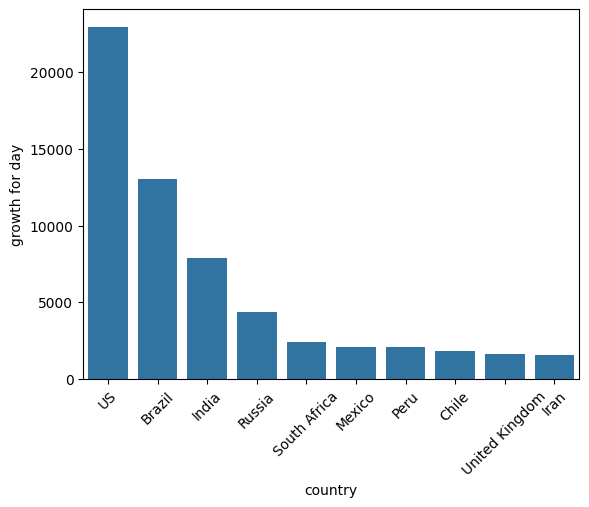

In [279]:
sns.barplot(data=growth,x='Country/Region',y='Daily_growth')
plt.xlabel('country')
plt.ylabel('growth for day')
plt.xticks(rotation=45)
plt.show()

In [280]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [281]:
data_set=df.groupby('Country/Region')[['Confirmed','Deaths','Recovered']].max().reset_index()
data_set

,Country/Region,Confirmed,Deaths,Recovered
0,Afghanistan,36263,1269,25198
1,Albania,4880,144,2745
2,Algeria,27973,1163,18837
3,Andorra,907,52,803
4,Angola,950,41,242
...,...,...,...,...
182,West Bank and Gaza,10621,78,3752
183,Western Sahara,10,1,8
184,Yemen,1691,483,833
185,Zambia,4552,140,2815


In [282]:
data_set['control_spread']=(((data_set['Confirmed']-data_set['Deaths']-data_set['Recovered'])/data_set['Confirmed'])*100).clip(lower=0)
data_set1=data_set[data_set['Confirmed']>10000].sort_values(by='control_spread',ascending=True).head(10)
data_set1

,Country/Region,Confirmed,Deaths,Recovered,control_spread
36,China,68135,4512,64435,0.000000
136,Qatar,109597,165,106328,2.832194
83,Ireland,25892,1764,23364,2.950718
65,Germany,207112,9125,190314,3.704759
47,Denmark,13547,613,12417,3.816343
162,Switzerland,34477,1978,30900,4.637875
172,Turkey,227019,5630,210469,4.810170
85,Italy,246286,35112,198593,5.108289
35,Chile,347923,9187,319954,5.398321
155,South Korea,14203,300,13007,6.308526


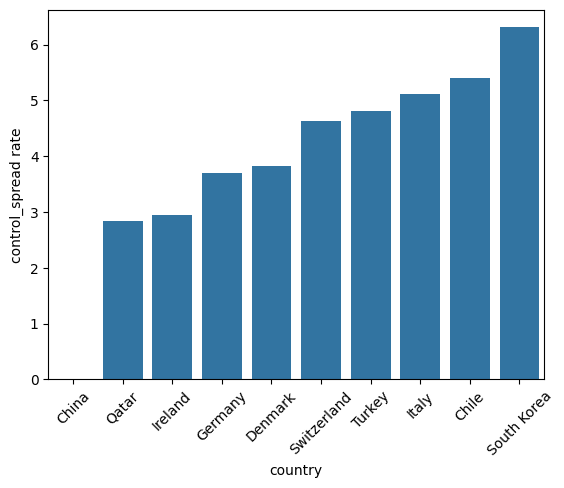

In [283]:
sns.barplot(data=data_set1,x='Country/Region',y='control_spread')
plt.xlabel('country')
plt.ylabel('control_spread rate')
plt.xticks(rotation=45)
plt.show()

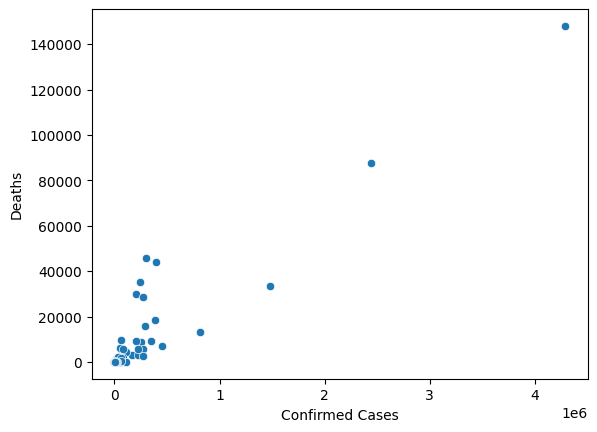

In [284]:
sns.scatterplot(data=data_set,x='Confirmed',y='Deaths')
plt.xlabel("Confirmed Cases")
plt.ylabel("Deaths")
plt.show()

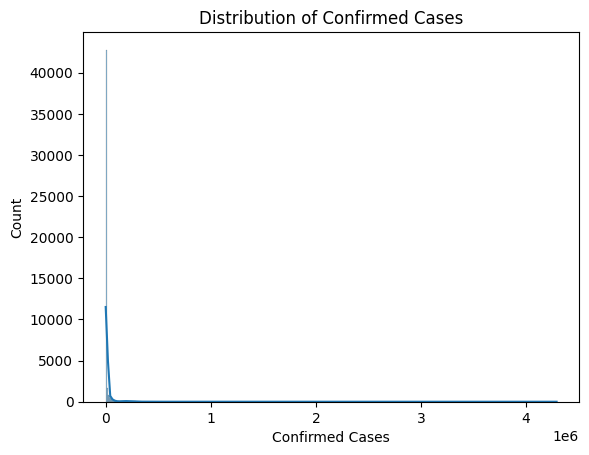

In [285]:
sns.histplot(df['Confirmed'],kde=True)
plt.title("Distribution of Confirmed Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Count")
plt.show()

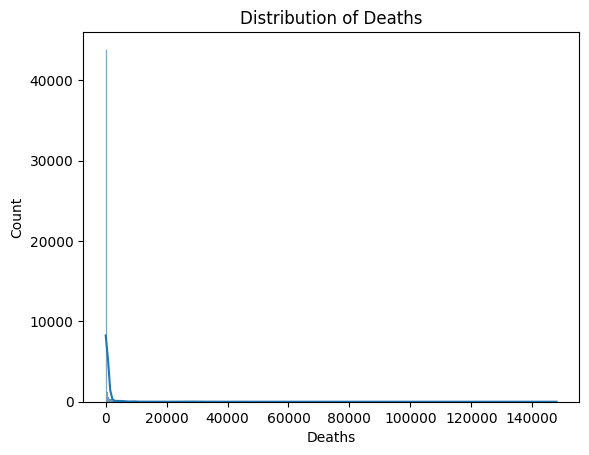

In [286]:
sns.histplot(df['Deaths'],kde=True)
plt.title("Distribution of Deaths")
plt.xlabel("Deaths")
plt.ylabel("Count")
plt.show()

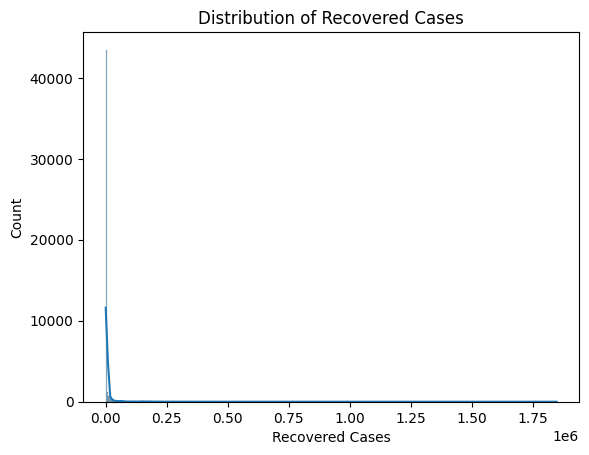

In [287]:
sns.histplot(df['Recovered'],kde=True)
plt.title("Distribution of Recovered Cases")
plt.xlabel("Recovered Cases")
plt.ylabel("Count")
plt.show()

# Q1: Why did you choose this chart? 
->It reveals the \skewness of continuous case counts across all recorded observations.  
# Q2: What insight can be extracted? 
The distribution is heavily right-skewed .

In [288]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='object')

In [289]:
top_affect=df.groupby('Country/Region')['Confirmed'].max().sort_values(ascending=False).head(10).reset_index()
top_affect

,Country/Region,Confirmed
0,US,4290259
1,Brazil,2442375
2,India,1480073
3,Russia,816680
4,South Africa,452529
5,Mexico,395489
6,Peru,389717
7,Chile,347923
8,United Kingdom,300111
9,Iran,293606


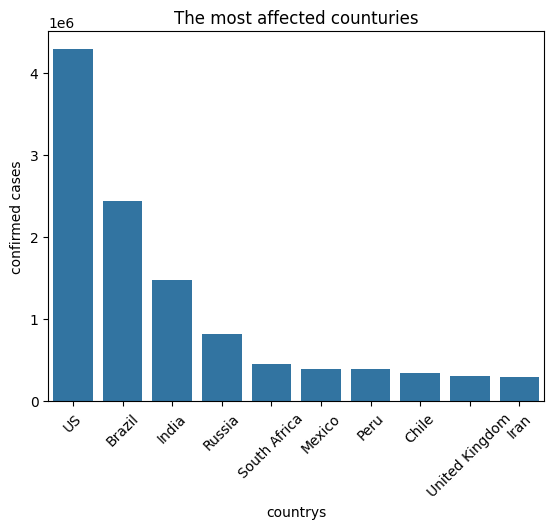

In [290]:
sns.barplot(data=top_affect,x='Country/Region',y='Confirmed')
plt.title('The most affected counturies')
plt.xlabel('countrys')
plt.ylabel('confirmed cases')
plt.xticks(rotation=45)
plt.show()

In [291]:
cases_dist=df.groupby('Date')[['Confirmed','Deaths','Recovered']].sum().reset_index()
cases_dist

,Date,Confirmed,Deaths,Recovered
0,2020-01-22,555,17,28
1,2020-01-23,654,18,30
2,2020-01-24,941,26,36
3,2020-01-25,1434,42,39
4,2020-01-26,2118,56,52
...,...,...,...,...
183,2020-07-23,15510481,633506,8710969
184,2020-07-24,15791645,639650,8939705
185,2020-07-25,16047190,644517,9158743
186,2020-07-26,16251796,648621,9293464


# Q1:Why did you choose this chart? 
A bar chart facilitates direct visual comparison and clear rank ordering of countries.  
# Q2: What insight can be extracted? 
COVID-19 burden was disproportionately concentrated in a few massive nations, with the US and Brazil together accounting for over a third of global confirmed infections.

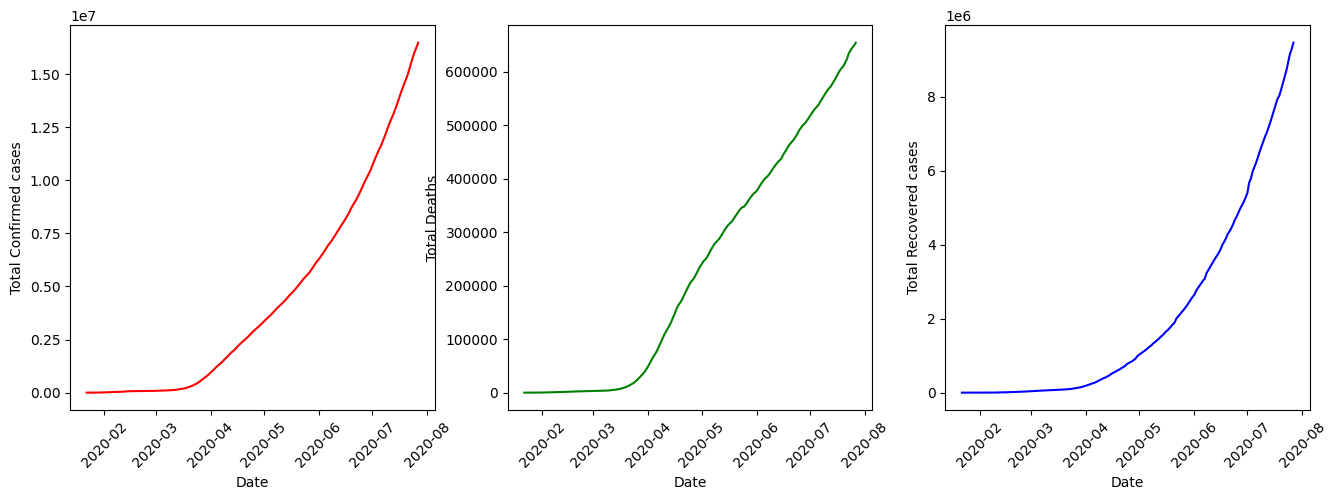

In [292]:
plt.figure(figsize=(16, 5))
plt.subplot(1,3,1)
plt.plot(cases_dist['Date'],cases_dist['Confirmed'],color='red')
plt.xlabel('Date')
plt.ylabel('Total Confirmed cases')
plt.xticks(rotation=45)

plt.subplot(1,3,2)
plt.plot(cases_dist['Date'],cases_dist['Deaths'],color='green')
plt.xlabel('Date')
plt.ylabel('Total Deaths')
plt.xticks(rotation=45)

plt.subplot(1,3,3)
plt.plot(cases_dist['Date'],cases_dist['Recovered'],color='blue')
plt.xlabel('Date')
plt.ylabel('Total Recovered cases')
plt.xticks(rotation=45)
plt.show()

# Q1: Why did you choose this chart? 
Line charts effectively depict chronological trends, and separate subplots grant each metric (Confirmed, Deaths, Recovered) an independent vertical scale to prevent smaller death counts from flattening visually. 
# Q2: What insight can be extracted? 
All three metrics follow an upward trajectory; however, recoveries begin accelerating dramatically by June 2020, while deaths demonstrate a more controlled gradient compared to overall infections.

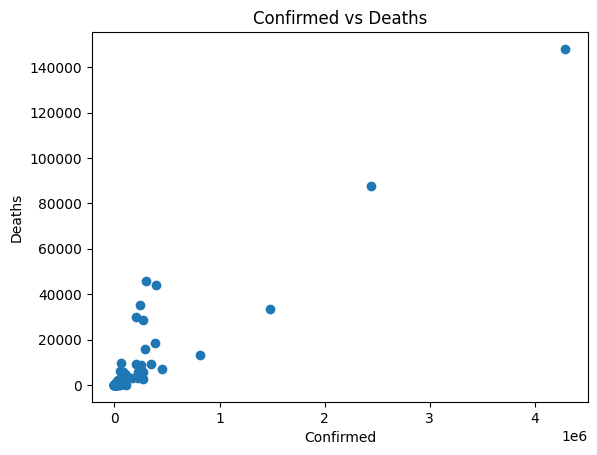

In [293]:
plt.scatter(data=data_set,x='Confirmed',y='Deaths')
plt.title('Confirmed vs Deaths')
plt.xlabel('Confirmed')
plt.ylabel('Deaths')
plt.show()

# Q1: Why did you choose this chart?
Scatter plots are the standard method for visualizing relationships, correlation strength, and outlier dispersion between two continuous variables.  
# Q2: What insight can be extracted? 
A strong positive correlation exists, but substantial dispersion is evident: some nations experienced significant death tolls with moderate caseloads, whereas others maintained low mortality despite high infection counts.

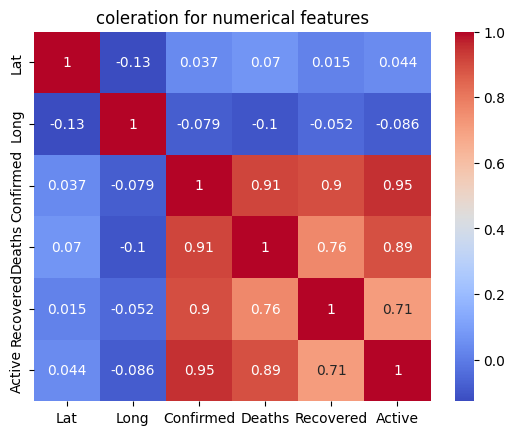

In [294]:
corelation=df.select_dtypes(include='number').corr()

sns.heatmap(corelation,annot=True,cmap='coolwarm')
plt.title('coleration for numerical features')
plt.show()

# Q1: Why did you choose this chart? 
A heatmap condenses pairwise correlation matrices into intuitive color-coded values with direct numerical annotations. 
# Q2: What insight can be extracted? 
Strong inter-correlation exists across case metrics, confirming direct clinical dependency. Geographical coordinates (Lat and Long) display near-zero correlation with severity, indicating that geography alone did not dictate vulnerability.  